In [79]:
import pandas as pd             # data package
import matplotlib.pyplot as plt # graphics 
import datetime as dt
import numpy as np
import os

In [82]:
matlist = pd.read_csv('hs10_classification_imports_exports.csv')

# matlist = pd.read_csv('hs10_datacenter_relevance.csv')

# Convert to category
matlist['relevance'] = matlist['relevance'].astype('category')

# Or specify order if needed (e.g., for sorting/comparisons)
matlist['relevance'] = pd.Categorical(
    matlist['relevance'], 
    categories=['Low', 'Medium', 'High'], 
    ordered=True
)

matlist['primary_category'] = matlist['primary_category'].astype('category')

matlist.rename(columns={'hs10_code': 'HS10'}, inplace=True)

print(matlist["relevance"].value_counts().reindex(["Low", "Medium", "High"]).to_string())

relevance
Low       20023
Medium     3265
High        829


In [83]:
matlist.head()

,relevance,confidence,primary_category,specific_use,reasoning,HS10,description,naics_code,naics_description
0,Low,100,Not_DC_Related,No application in data center context,Live purebred breeding horses are livestock us...,101210010,"HORSES, LIVE, PUREBRED BREEDING MALE",112920,HORSES AND OTHER EQUINE
1,Low,100,Not_DC_Related,Not applicable to data center construction or ...,Live horses are livestock animals with no conn...,101210020,"HORSES, LIVE, PUREBRED BREEDING FEMALE",112920,HORSES AND OTHER EQUINE
2,Low,100,Not_DC_Related,No application in data center construction or ...,Live horses are livestock animals with no rele...,101290090,"HORSES, LIVE, NESOI",112920,HORSES AND OTHER EQUINE
3,Low,100,Not_DC_Related,Not applicable - livestock animals have no rol...,Live donkeys/asses are livestock animals used ...,101300000,"ASSES, LIVE",112920,HORSES AND OTHER EQUINE
4,Low,100,Not_DC_Related,Not applicable to data center operations,Live cattle are agricultural livestock with no...,102210010,"CATTLE, LIVE, PUREBRED BREEDING MALE, DAIRY",11211X,Description not found for NAICS 11211X


In [84]:
df = pd.read_parquet('TOTALexports-combined.parquet')

df.rename(columns={'E_COMMODITY': 'HS10'}, inplace=True)

df["HS2"] = df["HS10"].str[0:2]
df["HS4"] = df["HS10"].str[0:4]

df["HS10"] = df["HS10"].astype('int64')

df.time = pd.to_datetime(df.time, format="%Y-%m")

df["exports"] = df["ALL_VAL_MO"].astype(float)

# df["duty"] = df["CAL_DUT_MO"].astype(float)

df.rename({"E_COMMODITY_SDESC": "short_description"}, axis = 1, inplace= True)

# # Remove volatile/special HS2 categories
# # These categories have prices that are either:
# # - Extremely volatile (oil, precious metals)
# # - Lumpy/irregular (aircraft)
# # - Unreliable/special (pharmaceuticals, special provisions)
excluded_hs2 = ["27", "71", "98", "99"]
df = df[~df["HS2"].isin(excluded_hs2)]

In [85]:
df.tail()

,CTY_NAME,ALL_VAL_MO,HS10,short_description,COMM_LVL,time,HS2,HS4,exports
1406551,TOTAL FOR ALL COUNTRIES,88666,6103410000,"M/B TROUSER OVERALLS SHORTS ETC WOOL, KNIT",HS10,2025-12-01,61,6103,88666.0
1406552,TOTAL FOR ALL COUNTRIES,2814441,6103420000,"M/B TROUSERS OVERALLS SHORTS ETC COTTON, KNIT",HS10,2025-12-01,61,6103,2814441.0
1406553,TOTAL FOR ALL COUNTRIES,8852855,6103430000,"M/B TROUSERS OVERALLS SHORTS ETC SYN FIBERS, KNIT",HS10,2025-12-01,61,6103,8852855.0
1406554,TOTAL FOR ALL COUNTRIES,30998,6103491500,"M/B TROUSERS OVERALLS SHORTS ETC ART FIBERS, KNIT",HS10,2025-12-01,61,6103,30998.0
1406555,TOTAL FOR ALL COUNTRIES,216336,6103493000,"M/B TROUSERS OVERALLS SHORTS ETC OT TEX MTRL, ...",HS10,2025-12-01,61,6103,216336.0


In [86]:
# Merge Relevance category from matlist onto df
df = df.merge(matlist[['HS10', 'relevance', 'primary_category', "reasoning"	]], on='HS10', how='left')

In [87]:

# Merge quality check
n_total = len(df)
n_matched = df['relevance'].notna().sum()
n_dropped = df['relevance'].isna().sum()

unique_hs10_total = df['HS10'].nunique()
unique_hs10_matched = df.loc[df['relevance'].notna(), 'HS10'].nunique()
unique_hs10_unmatched = df.loc[df['relevance'].isna(), 'HS10'].nunique()

exports_total = df['exports'].sum()
exports_matched = df.loc[df['relevance'].notna(), 'exports'].sum()
exports_dropped = df.loc[df['relevance'].isna(), 'exports'].sum()

print(f"=== Merge Check ===")
print(f"Total rows:          {n_total:>10,}")
print(f"  Matched rows:      {n_matched:>10,}  ({100*n_matched/n_total:.1f}%)")
print(f"  Unmatched rows:    {n_dropped:>10,}  ({100*n_dropped/n_total:.1f}%)")
print()
print(f"Unique HS10 codes:   {unique_hs10_total:>10,}")
print(f"  Matched:           {unique_hs10_matched:>10,}  ({100*unique_hs10_matched/unique_hs10_total:.1f}%)")
print(f"  Unmatched:         {unique_hs10_unmatched:>10,}  ({100*unique_hs10_unmatched/unique_hs10_total:.1f}%)")
print()
print(f"Export value ($):    {exports_total:>14,.0f}")
print(f"  Matched:           {exports_matched:>14,.0f}  ({100*exports_matched/exports_total:.1f}%)")
print(f"  Unmatched:         {exports_dropped:>14,.0f}  ({100*exports_dropped/exports_total:.1f}%)")
print()
print(f"Relevance breakdown:")
print(df['relevance'].value_counts(dropna=False).to_string())

# --- Are all High relevance HS10 codes from matlist present in df? ---
print()
print(f"=== High Relevance Coverage Check ===")
high_in_matlist = set(matlist.loc[matlist['relevance'] == 'High', 'HS10'])
high_in_df      = set(df.loc[df['relevance'] == 'High', 'HS10'])
missing_high    = high_in_matlist - high_in_df

print(f"High relevance codes in matlist:  {len(high_in_matlist):>6,}")
print(f"High relevance codes found in df: {len(high_in_df):>6,}")
print(f"Missing from df:                  {len(missing_high):>6,}")
if missing_high:
    print(f"\nHS10 codes in matlist (High) but absent from df:")
    for code in sorted(missing_high):
        desc = matlist.loc[matlist['HS10'] == code, 'reasoning'].values
        print(f"  {code}  —  {desc[0][:80] if len(desc) else 'n/a'}")
else:
    print("\nAll High relevance HS10 codes from matlist are present in df.")


=== Merge Check ===
Total rows:           1,379,404
  Matched rows:       1,379,404  (100.0%)
  Unmatched rows:             0  (0.0%)

Unique HS10 codes:       10,480
  Matched:               10,480  (100.0%)
  Unmatched:                  0  (0.0%)

Export value ($):    18,137,751,445,464
  Matched:           18,137,751,445,464  (100.0%)
  Unmatched:                      0  (0.0%)

Relevance breakdown:
relevance
Low       1080247
Medium     227615
High        71542

=== High Relevance Coverage Check ===
High relevance codes in matlist:     829
High relevance codes found in df:    534
Missing from df:                     295

HS10 codes in matlist (High) but absent from df:
  2710124545  —  This is transformer oil, which is essential for electrical transformers used in 
  2710190615  —  No. 4 fuel oil is a heavy distillate fuel commonly used in large stationary dies
  2710190630  —  Fuel Oil No. 6 is a heavy fuel oil commonly used in large backup generators and 
  2710190650  —  Heavy f

In [88]:
grp = df.groupby(['relevance', 'time'], observed=True)

grp_sum = grp[['exports']].sum().reset_index()

grp = df.groupby(['time'], observed=True)

grp_total = grp[['exports']].sum().reset_index()

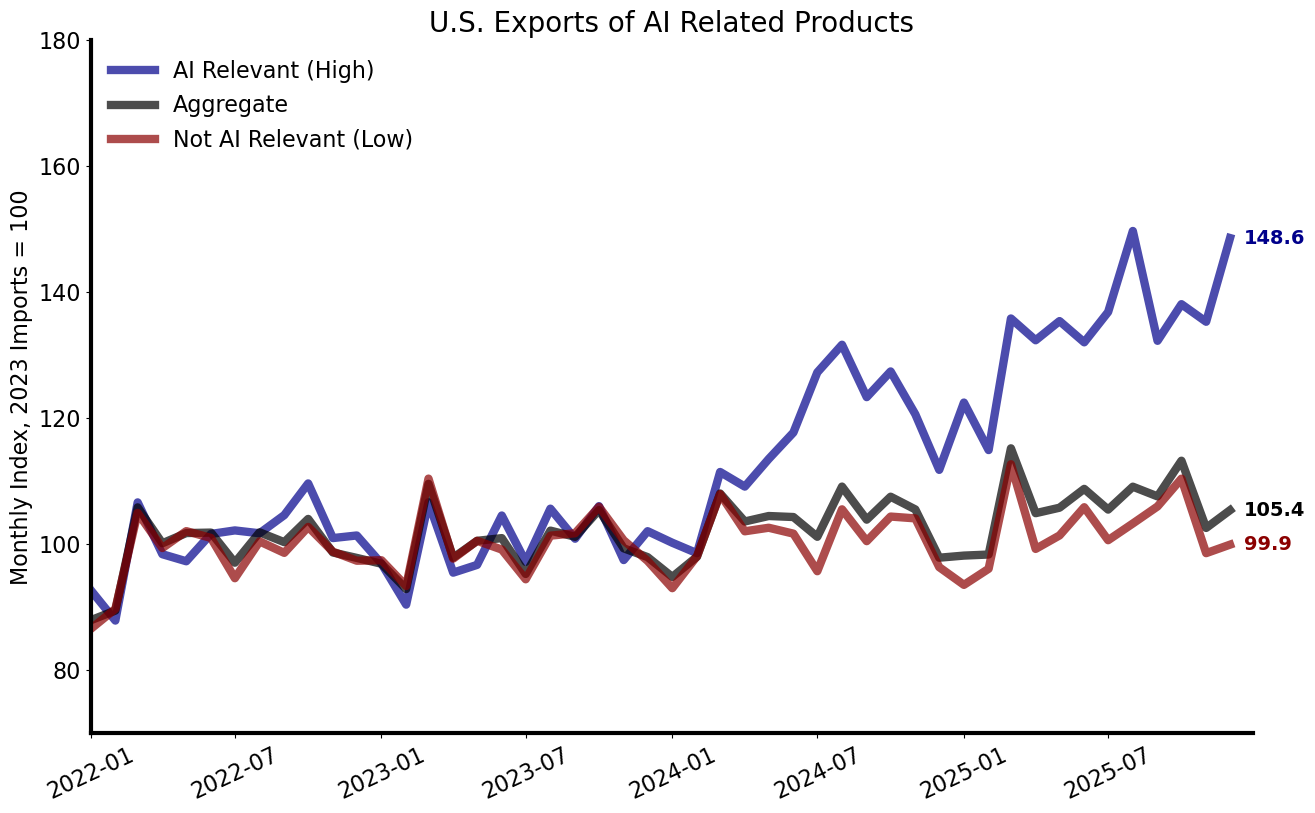

In [101]:
fig, ax = plt.subplots(figsize = (15,9))

foo = grp_sum[grp_sum['relevance']=='High'].copy()
foo.set_index('time', inplace=True)
ax.plot(foo.index, 100*(12*foo["exports"] / foo["exports"].loc["2023"].sum()) , 
        color = "darkblue", alpha = 0.7, linewidth = 6, label='AI Relevant (High)')

foo2 = grp_total.copy()
foo2.set_index('time', inplace=True)
ax.plot(foo2.index, 100*(12*foo2["exports"] / foo2["exports"].loc["2023"].sum()) ,
         color = "black", alpha = 0.7, linewidth = 6, label='Aggregate')

foo3 = grp_sum[grp_sum['relevance']=='Low'].copy()
foo3.set_index('time', inplace=True)
ax.plot(foo3.index, 100*(12*foo3["exports"] / foo3["exports"].loc["2023"].sum()) ,
         color = "darkred", alpha = 0.7, linewidth = 6, label='Not AI Relevant (Low)')

# Add annotations for last observations
last_date_ai = foo.index[-1]
last_value_ai = 100*(12*foo["exports"].iloc[-1] / foo["exports"].loc["2023"].sum())
ax.annotate(f'{last_value_ai:.1f}', 
            xy=(last_date_ai, last_value_ai),
            xytext=(10, 0), textcoords='offset points',
            fontsize=14, fontweight='bold', color='darkblue',
            va='center')

last_date_agg = foo2.index[-1]
last_value_agg = 100*(12*foo2["exports"].iloc[-1] / foo2["exports"].loc["2023"].sum())
ax.annotate(f'{last_value_agg:.1f}', 
            xy=(last_date_agg, last_value_agg),
            xytext=(10, 0), textcoords='offset points',
            fontsize=14, fontweight='bold', color='black',
            va='center')

last_date_not_ai = foo3.index[-1]
last_value_not_ai = 100*(12*foo3["exports"].iloc[-1] / foo3["exports"].loc["2023"].sum())
ax.annotate(f'{last_value_not_ai:.1f}', 
            xy=(last_date_not_ai, last_value_not_ai),
            xytext=(10, 0), textcoords='offset points',
            fontsize=14, fontweight='bold', color='darkred',
            va='center')

ax.set_title("U.S. Exports of AI Related Products", fontsize = 20)

ax.set_xlim([dt.datetime(2022,1,1), dt.datetime(2025,12,30)])

ax.set_ylim(70,180)

ax.tick_params(axis='x', labelsize=16, rotation=25)
ax.tick_params(axis='y', labelsize=16)

ax.set_ylabel("Monthly Index, 2023 Imports = 100", fontsize=16)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(3)
ax.spines["bottom"].set_linewidth(3)

ax.legend(
    fontsize=16,
    frameon=False,
    loc='upper left',
    ncol=1
)

# plt.savefig(figfile+"ai-trade-index.png", bbox_inches = "tight")
# plt.savefig(figfile+"ai-trade-index.pdf", bbox_inches = "tight")

plt.show()

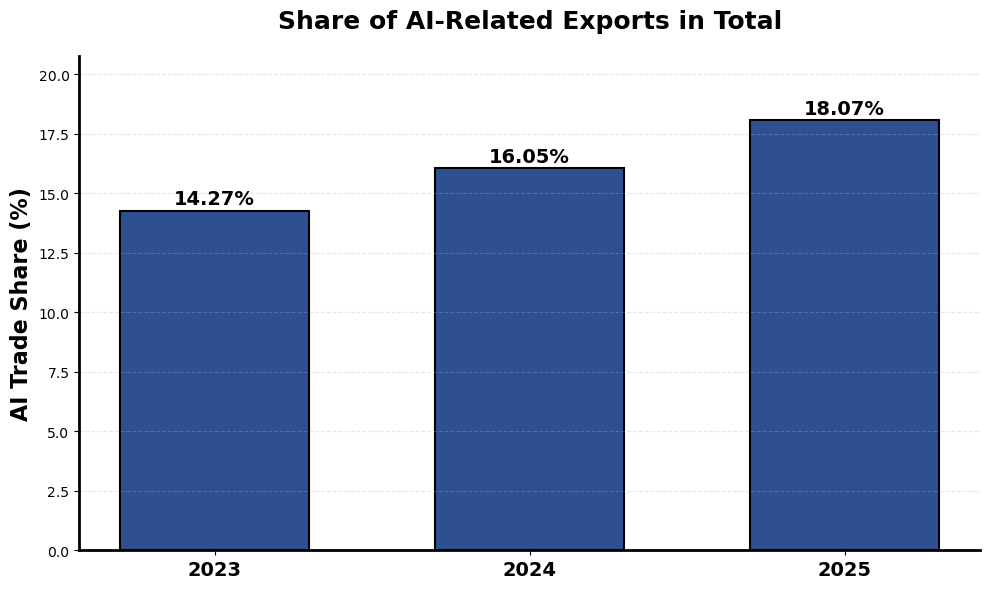


AI Trade Share:
  2023: 14.27%
  2024: 16.05%
  2025: 18.07%

Growth: 3.80 percentage points


In [90]:
# Calculate AI trade share for each year (2023-2025)
years = [2023, 2024, 2025]
ai_shares = []

foo = grp_sum[grp_sum['relevance']=='High'].copy().set_index("time")
df_indexed = df.set_index("time")  # local view — does not mutate df

for year in years:
    year_str = str(year)
    total_trade = df_indexed.exports.loc[year_str].sum()
    ai_trade = foo.exports.loc[year_str].sum()
    ai_share = (ai_trade / total_trade) * 100
    ai_shares.append(ai_share)

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(years, ai_shares, color='#2E5090', edgecolor='black', linewidth=1.5, width=0.6)

# Add value labels on bars
for i, (year, share) in enumerate(zip(years, ai_shares)):
    ax.text(year, share + 0.1, f'{share:.2f}%', 
            ha='center', va='bottom', fontsize=14, fontweight='bold')

# Formatting
# ax.set_xlabel('Year', fontsize=16, fontweight='bold')
ax.set_ylabel('AI Trade Share (%)', fontsize=16, fontweight='bold')
ax.set_title('Share of AI-Related Exports in Total', fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(years)
ax.set_ylim(0, max(ai_shares) * 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Make x-tick labels bold and larger
ax.tick_params(axis='x', labelsize=14)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout()
plt.show()

print(f"\nAI Trade Share:")
for year, share in zip(years, ai_shares):
    print(f"  {year}: {share:.2f}%")
print(f"\nGrowth: {ai_shares[-1] - ai_shares[0]:.2f} percentage points")


In [91]:
# Calculate values for the table
df_reset = df.reset_index()

# Count unique HS10 codes by relevance
high_hs_count = df_reset[df_reset['relevance'] == 'High']['HS10'].nunique()
low_hs_count = df_reset[df_reset['relevance'] == 'Low']['HS10'].nunique()
total_hs_count = df_reset[df_reset['time'].dt.year == 2024]['HS10'].nunique()

# 2023 values
high_2023 = df_reset[(df_reset['time'].dt.year == 2023) & (df_reset['relevance'] == 'High')]['exports'].sum()
low_2023 = df_reset[(df_reset['time'].dt.year == 2023) & (df_reset['relevance'] == 'Low')]['exports'].sum()
total_2023 = df_reset[df_reset['time'].dt.year == 2023]['exports'].sum()

# 2025 values
high_2025 = df_reset[(df_reset['time'].dt.year == 2025) & (df_reset['relevance'] == 'High')]['exports'].sum()
low_2025 = df_reset[(df_reset['time'].dt.year == 2025) & (df_reset['relevance'] == 'Low')]['exports'].sum()
total_2025 = df_reset[df_reset['time'].dt.year == 2025]['exports'].sum()

# Calculate percent increases
high_pct = ((high_2025 - high_2023) / high_2023) * 100
low_pct = ((low_2025 - low_2023) / low_2023) * 100
total_pct = ((total_2025 - total_2023) / total_2023) * 100

In [92]:
# Calculate values for the table
df_reset = df.reset_index()

# Get high relevance only
df_high_only = df_reset[df_reset['relevance'] == 'High'].copy()

# Get all categories (excluding Not_DC_Related, Maintenance_Operations, and NaN)
all_cats = [cat for cat in df_high_only['primary_category'].unique() 
            if pd.notna(cat) and cat != 'Not_DC_Related' and cat != 'Maintenance_Operations']

category_data = {}
for cat in all_cats:
    cat_data = df_high_only[df_high_only['primary_category'] == cat]
    
    # Count unique HS10 codes
    hs_count = cat_data['HS10'].nunique()
    
    # 2023 values
    cat_2023 = cat_data[cat_data['time'].dt.year == 2023]['exports'].sum()
    
    # 2025 values
    cat_2025 = cat_data[cat_data['time'].dt.year == 2025]['exports'].sum()
    
    # Calculate percent increase
    cat_pct = ((cat_2025 - cat_2023) / cat_2023) * 100 if cat_2023 > 0 else 0
    
    category_data[cat] = {
        'hs_count': hs_count,
        '2023': cat_2023,
        '2025': cat_2025,
        'pct': cat_pct
    }

# Calculate totals for High AI Relevance
# Sort categories by 2023 dollar value (descending)
all_cats = sorted(category_data.keys(), key=lambda x: category_data[x]['2023'], reverse=True)

# Calculate totals for High AI Relevance
total_high_hs_count = df_high_only['HS10'].nunique()
total_high_2023 = df_high_only[df_high_only['time'].dt.year == 2023]['exports'].sum()
total_high_2025 = df_high_only[df_high_only['time'].dt.year == 2025]['exports'].sum()
total_high_pct = ((total_high_2025 - total_high_2023) / total_high_2023) * 100

In [93]:
# Generate combined hierarchical LaTeX table for trade values
# Shows High AI Relevance with subcategories, then Low AI Relevance, then Total

import os
os.makedirs('tables', exist_ok=True)

# Use the data already calculated in previous cells
# high_hs_count, high_2023, high_2025, high_pct (from relevance table)
# low_hs_count, low_2023, low_2025, low_pct (from relevance table)
# total_hs_count, total_2023, total_2025, total_pct (from relevance table)
# category_data, all_cats (from category table)

# Generate combined hierarchical table
table_file = "tables/trade_hierarchical_exports.tex"
with open(table_file, 'w', encoding='utf-8') as f:
    f.write("\\begin{table}[htbp]\n")
    f.write("\\centering\n")
    f.write("\\caption{U.S. Export Values by AI Relevance and Category (2023 vs 2025)}\n")
    f.write("\\label{tab:trade_hierarchical_exports}\n")
    f.write("\\setlength{\\tabcolsep}{4.5mm}\n")
    f.write("\\renewcommand{\\arraystretch}{1.60}\n")
    f.write("\\begin{tabular}{lrrrr}\n")
    f.write("\\toprule\n")
    f.write("Category & \\# HS10 Codes & 2023 (\\$B) & 2025 (\\$B) & Change (\\%) \\\\\n")
    f.write("\\midrule\n")
    
    # High AI Relevance (main row)
    f.write(f"High AI Relevance & {high_hs_count} & {high_2023/1e9:.1f} & {high_2025/1e9:.1f} & {high_pct:+.1f} \\\\\n")
    
    # Subcategories (indented)
    for cat in all_cats:
        cat_name = cat.replace('_', ' ')
        data = category_data[cat]
        # Use \quad\quad for indentation
        f.write(f"\\quad\\quad {cat_name} & {data['hs_count']} & {data['2023']/1e9:.1f} & {data['2025']/1e9:.1f} & {data['pct']:+.1f} \\\\\n")
    
    # Low AI Relevance
    f.write(f"Low AI Relevance & {low_hs_count} & {low_2023/1e9:.1f} & {low_2025/1e9:.1f} & {low_pct:+.1f} \\\\\n")
    
    f.write("\\midrule\n")
    
    # Total Trade
    f.write(f"Total Trade & {total_hs_count} & {total_2023/1e9:.1f} & {total_2025/1e9:.1f} & {total_pct:+.1f} \\\\\n")
    
    f.write("\\bottomrule\n")
    f.write("\\end{tabular}\n")
    f.write("\\end{table}\n")

print(f"Generated: {table_file}\n")
print("LaTeX Table:")
print("="*80)
with open(table_file, 'r', encoding='utf-8') as f:
    print(f.read())
print("="*80)
print("\nSummary:")
print(f"High AI Relevance: {high_hs_count} HS10 codes | ${high_2023/1e9:.1f}B (2023) → ${high_2025/1e9:.1f}B (2025) [{high_pct:+.1f}%]")
for cat in all_cats:
    data = category_data[cat]
    cat_name = cat.replace('_', ' ')
    print(f"  └─ {cat_name}: {data['hs_count']} HS10 codes | ${data['2023']/1e9:.1f}B (2023) → ${data['2025']/1e9:.1f}B (2025) [{data['pct']:+.1f}%]")
print(f"Low AI Relevance: {low_hs_count} HS10 codes | ${low_2023/1e9:.1f}B (2023) → ${low_2025/1e9:.1f}B (2025) [{low_pct:+.1f}%]")
print(f"Total Trade: {total_hs_count} HS10 codes | ${total_2023/1e9:.1f}B (2023) → ${total_2025/1e9:.1f}B (2025) [{total_pct:+.1f}%]")




Generated: tables/trade_hierarchical_exports.tex

LaTeX Table:
\begin{table}[htbp]
\centering
\caption{U.S. Export Values by AI Relevance and Category (2023 vs 2025)}
\label{tab:trade_hierarchical_exports}
\setlength{\tabcolsep}{4.5mm}
\renewcommand{\arraystretch}{1.60}
\begin{tabular}{lrrrr}
\toprule
Category & \# HS10 Codes & 2023 (\$B) & 2025 (\$B) & Change (\%) \\
\midrule
High AI Relevance & 534 & 221.5 & 297.9 & +34.5 \\
\quad\quad Compute Hardware & 112 & 99.1 & 160.6 & +62.1 \\
\quad\quad Electrical Power & 219 & 64.5 & 70.1 & +8.8 \\
\quad\quad Networking Telecom & 23 & 29.1 & 37.7 & +29.7 \\
\quad\quad Cooling HVAC & 128 & 24.1 & 25.0 & +3.5 \\
\quad\quad Building Structure & 28 & 3.0 & 2.8 & -6.8 \\
\quad\quad Specialty Materials & 16 & 0.7 & 0.6 & -9.6 \\
\quad\quad Fire Safety Security & 7 & 0.5 & 0.6 & +13.4 \\
Low AI Relevance & 8278 & 1034.8 & 1058.6 & +2.3 \\
\midrule
Total Trade & 9269 & 1551.9 & 1648.4 & +6.2 \\
\bottomrule
\end{tabular}
\end{table}


Summary:
High A

In [94]:
# Top 5 HS10 codes within each top category (High relevance only)

top_4_cats = ['Compute_Hardware', 'Electrical_Power', 'Networking_Telecom', 'Cooling_HVAC']

df_reset = df.reset_index()
df_high_only = df_reset[df_reset['relevance'] == 'High'].copy()

for cat in top_4_cats:
    print(f"\n{'='*80}")
    print(f"{cat.replace('_', ' ')}")
    print('='*80)
    
    # Filter to this category
    cat_data = df_high_only[df_high_only['primary_category'] == cat].copy()
    
    # Get total exports for this category
    cat_total = cat_data['exports'].sum()
    
    # Group by HS10 and sum exports
    hs10_exports = cat_data.groupby('HS10')['exports'].sum().sort_values(ascending=False)
    
    # Get top 5
    top_5_hs10 = hs10_exports.head(5)
    
    # Get descriptions from df and matlist
    for rank, (hs10, exports) in enumerate(top_5_hs10.items(), 1):
        fraction = (exports / cat_total) * 100
        
        # Get description from df and reasoning from matlist
        desc_row_df = cat_data[cat_data['HS10'] == hs10]
        desc_row_matlist = matlist[matlist['HS10'] == hs10]
        
        if len(desc_row_df) > 0:
            description = desc_row_df.iloc[0].get('short_description', 'No description available')
        else:
            description = 'Description not found'
            
        if len(desc_row_matlist) > 0:
            llm_reasoning = desc_row_matlist.iloc[0].get('reasoning', 'No reasoning available')
        else:
            llm_reasoning = 'Reasoning not found'

        
        print(f"   Reasoning: {llm_reasoning}")
        print(f"\n{rank}. HS10: {hs10}")        
        print(f"   Description: {description}")
        print(f"   Share of {cat.replace('_', ' ')}: {fraction:.2f}%")


Compute Hardware
   Reasoning: This HS10 code covers processors and controllers, which are essential compute components in AI data centers. These include CPUs that power servers, control systems, and work alongside GPUs in AI training and inference workloads. High confidence due to direct application in data center compute infrastructure.

1. HS10: 8542310000
   Description: PROCESSORS & CONTOLLERS W/NOT COMBO W MEMORIS, ETC
   Share of Compute Hardware: 19.54%
   Reasoning: HS 8471 covers automatic data processing machines (computers), so parts and accessories for these machines would include server components, memory modules, storage devices, cooling fans, power supplies, and other critical hardware used in AI data center compute infrastructure

2. HS10: 8473300002
   Description: PARTS & ACCESSORIES FOR MACHINES OF 8471
   Share of Compute Hardware: 17.59%
   Reasoning: Digital processing units are core compute components used in data center servers. The NAICS classification confir

In [95]:
# DATA PREPARATION: Calculate shares and prepare data for category comparisons

# Get all categories except Not_DC_Related
ai_categories = [cat for cat in matlist['primary_category'].unique() 
                 if cat != 'Not_DC_Related' and pd.notna(cat)]
ai_categories = sorted(ai_categories)

# Calculate total high AI trade and share for each category
df_reset = df.reset_index()
high_ai_total = df_reset[df_reset['relevance'] == 'High']['exports'].sum()

category_shares = {}
for cat in ai_categories:
    cat_data = df_reset[(df_reset['primary_category'] == cat) & 
                        (df_reset['relevance'] == 'High')]
    cat_imports = cat_data['exports'].sum()
    share = (cat_imports / high_ai_total) * 100
    category_shares[cat] = share

# Sort by share (descending) and take top 8
top_categories = sorted(category_shares.items(), key=lambda x: x[1], reverse=True)[:8]

# Create grouped data for plotting - ONLY HIGH RELEVANCE for AI categories
df_high = df_reset[df_reset['relevance'] == 'High'].copy()
grp_cat = df_high.groupby(['primary_category', 'time'], observed=True)
grp_cat_sum = grp_cat[['exports']].sum().reset_index()

# Get Not_DC_Related data (all relevance levels)
not_dc_all = df_reset[df_reset['primary_category'] == 'Not_DC_Related'].copy()
grp_not_dc = not_dc_all.groupby(['time'], observed=True)
not_dc_sum = grp_not_dc[['exports']].sum().reset_index()
not_dc_sum.set_index('time', inplace=True)

print("\nAI Category Shares of Total High AI Trade:")
for cat, share in top_categories:
    print(f"  {cat.replace('_', ' ')}: {share:.2f}%")


AI Category Shares of Total High AI Trade:
  Compute Hardware: 47.47%
  Electrical Power: 27.32%
  Networking Telecom: 13.10%
  Cooling HVAC: 10.18%
  Building Structure: 1.24%
  Maintenance Operations: 0.24%
  Specialty Materials: 0.24%
  Fire Safety Security: 0.20%


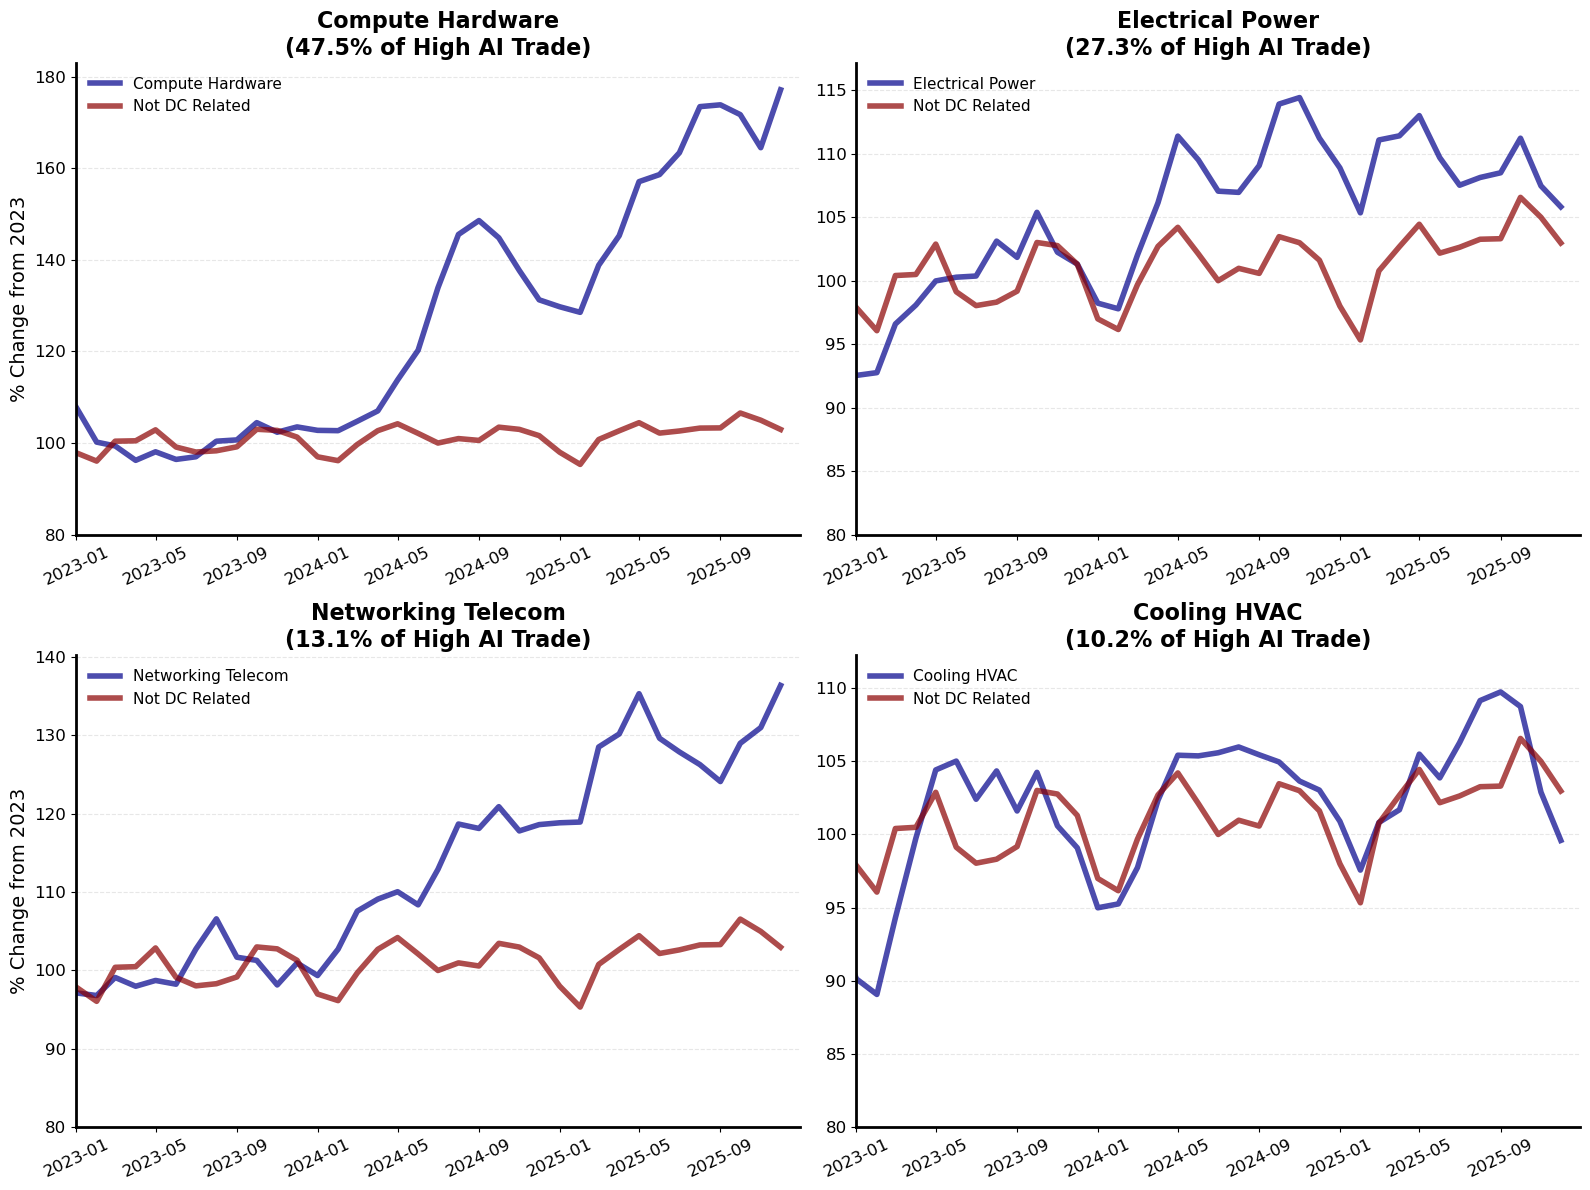

In [96]:
# PLOT TOP 4 CATEGORIES (2x2 panel)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (cat, share) in enumerate(top_categories[:4]):
    ax = axes[idx]
    
    # Get AI category data (High relevance only)
    cat_data = grp_cat_sum[grp_cat_sum['primary_category'] == cat].copy()
    cat_data.set_index('time', inplace=True)
    
    # Normalize to 2023 = 100
    if len(cat_data) > 0 and '2023' in cat_data.index:
        cat_2023_sum = cat_data["exports"].loc["2023"].sum()
        ax.plot(cat_data.index, (100*(12*cat_data["exports"] / cat_2023_sum)).rolling(window=3).mean(),
                color="darkblue", alpha=0.7, linewidth=4, label=cat.replace('_', ' '))
    
    # Plot Not_DC_Related data (all relevance levels)
    if len(not_dc_sum) > 0 and '2023' in not_dc_sum.index:
        not_dc_2023_sum = not_dc_sum["exports"].loc["2023"].sum()
        ax.plot(not_dc_sum.index, (100*(12*not_dc_sum["exports"] / not_dc_2023_sum)).rolling(window=3).mean(),
                color="darkred", alpha=0.7, linewidth=4, label='Not DC Related')
    
    # Formatting
    ax.set_title(f"{cat.replace('_', ' ')}\n({share:.1f}% of High AI Trade)", 
                 fontsize=16, fontweight='bold')
    ax.set_xlim([dt.datetime(2023,1,1), dt.datetime(2025,12,30)])
    ax.set_ylim(80,)
    ax.tick_params(axis='x', labelsize=12, rotation=25)
    ax.tick_params(axis='y', labelsize=12)
    
    if idx >= 2:  # Bottom row
        ax.set_xlabel("")
    if idx % 2 == 0:  # Left column
        ax.set_ylabel("% Change from 2023", fontsize=14)
    
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    
    ax.legend(fontsize=11, frameon=False, loc='upper left')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [97]:
# # Plot HS code 8542310040 over time in dollar values
# hs_code = 8415908085
# df_reset = df.reset_index()
# hs_data = df_reset[df_reset['HS10'] == hs_code].copy()
# hs_data_grouped = hs_data.groupby('time')['exports'].sum().reset_index()
# hs_data_grouped.set_index('time', inplace=True)

# fig, ax = plt.subplots(figsize=(12, 6))
# ax.plot(hs_data_grouped.index, hs_data_grouped['exports'] / 1e9, 
#         color='darkblue', linewidth=3, marker='o', markersize=4)

# ax.set_title(f'U.S. Imports of HS10 Code {hs_code}', fontsize=16, fontweight='bold')
# ax.set_ylabel('Imports ($B)', fontsize=14, fontweight='bold')
# ax.set_xlim([dt.datetime(2023,1,1), dt.datetime(2025,12,31)])
# ax.tick_params(axis='x', labelsize=12, rotation=25)
# ax.tick_params(axis='y', labelsize=12)
# ax.grid(axis='y', alpha=0.3, linestyle='--')

# ax.spines["right"].set_visible(False)
# ax.spines["top"].set_visible(False)
# ax.spines["left"].set_linewidth(2)
# ax.spines["bottom"].set_linewidth(2)

# plt.tight_layout()
# plt.show()

# print(f"\nHS10 Code {hs_code} Summary:")
# print(f"  Total imports (all time): ${hs_data_grouped['exports'].sum()/1e9:.2f}B")
# print(f"  Average monthly: ${hs_data_grouped['exports'].mean()/1e9:.2f}B")

In [98]:
dfcountry = pd.read_parquet('ALL-country-exports.parquet')

dfcountry.rename(columns={'E_COMMODITY': 'HS10'}, inplace=True)

dfcountry["HS2"] = dfcountry["HS10"].str[0:2]
dfcountry["HS4"] = dfcountry["HS10"].str[0:4]

dfcountry["HS10"] = dfcountry["HS10"].astype('int64')

dfcountry.time = pd.to_datetime(dfcountry.time, format="%Y-%m")

dfcountry["exports"] = dfcountry["ALL_VAL_MO"].astype(float)


dfcountry.rename({"E_COMMODITY_SDESC": "short_description"}, axis = 1, inplace= True)

# Remove volatile/special HS2 categories
# These categories have prices that are either:
# - Extremely volatile (oil, precious metals)
# - Lumpy/irregular (aircraft)
# - Unreliable/special (pharmaceuticals, special provisions)
excluded_hs2 = ["27", "71", "98", "99"]
dfcountry = dfcountry[~dfcountry["HS2"].isin(excluded_hs2)]

excluded_cntry = ["TOTAL FOR ALL COUNTRIES", "USMCA (NAFTA)", "EUROPEAN UNION"]
dfcountry = dfcountry[~dfcountry["CTY_NAME"].isin(excluded_cntry)]

# Merge Relevance category from matlist onto df
dfcountry = dfcountry.merge(matlist[['HS10', 'relevance', 'primary_category', "reasoning"	]], on='HS10', how='left')

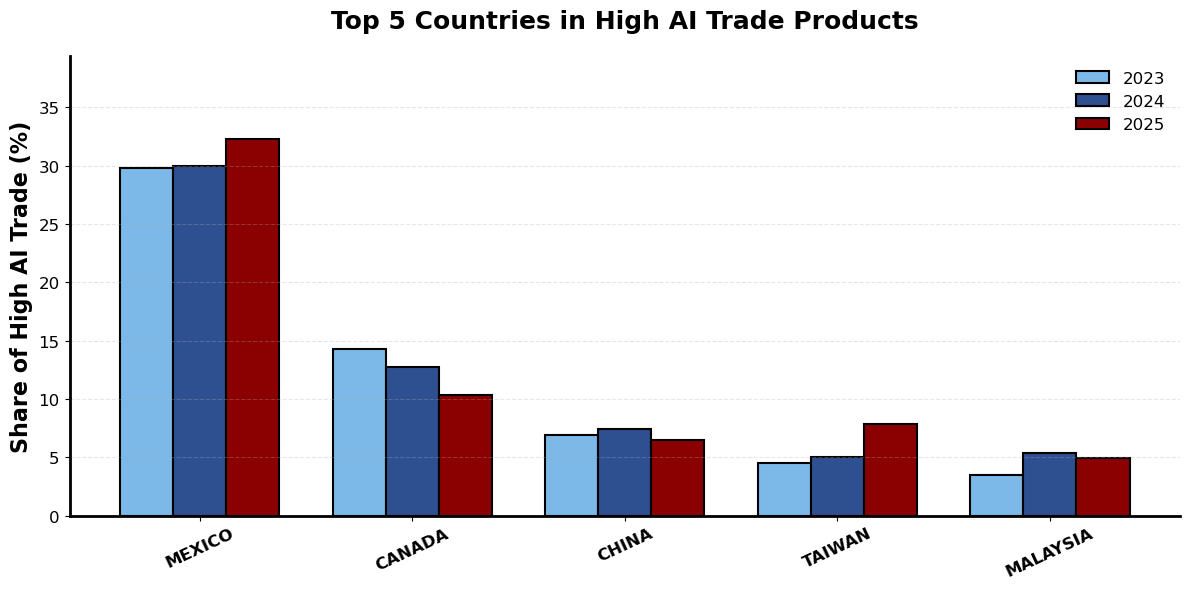

In [99]:
# Top 5 countries in High AI trade products, split by year (2023, 2024, 2025)

period_years = [2023, 2024, 2025]

country_high = dfcountry[
    (dfcountry['relevance'] == 'High') &
    (dfcountry['time'].dt.year.isin(period_years))
] .copy()

# Select top 5 countries based on combined 2024-2025 imports
country_exports_total = (
    country_high[country_high['time'].dt.year.isin([2024, 2025])]
    .groupby('CTY_NAME', observed=True)['exports']
    .sum()
    .sort_values(ascending=False)
)
top5_countries = country_exports_total.head(5).index.tolist()

# Compute yearly shares: country high-AI exports / total high-AI exports in that year
yearly_country_exports = (
    country_high[country_high['CTY_NAME'].isin(top5_countries)]
    .groupby(['CTY_NAME', country_high['time'].dt.year], observed=True)['exports']
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=period_years, fill_value=0)
)

yearly_high_totals = (
    country_high.groupby(country_high['time'].dt.year, observed=True)['exports']
    .sum()
)

plot_df = pd.DataFrame({
    '2023': (yearly_country_exports[2023] / yearly_high_totals.loc[2023]) * 100,
    '2024': (yearly_country_exports[2024] / yearly_high_totals.loc[2024]) * 100,
    '2025': (yearly_country_exports[2025] / yearly_high_totals.loc[2025]) * 100
}).loc[top5_countries]

# Plot grouped bars
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(plot_df.index))
width = 0.25

bars_2023 = ax.bar(
    x - width,
    plot_df['2023'].values,
    width,
    label='2023',
    color='#7CB9E8',
    edgecolor='black',
    linewidth=1.5
)

bars_2024 = ax.bar(
    x,
    plot_df['2024'].values,
    width,
    label='2024',
    color='#2E5090',
    edgecolor='black',
    linewidth=1.5
)

bars_2025 = ax.bar(
    x + width,
    plot_df['2025'].values,
    width,
    label='2025',
    color='#8B0000',
    edgecolor='black',
    linewidth=1.5
)

# Formatting (consistent with existing style)
ax.set_ylabel('Share of High AI Trade (%)', fontsize=16, fontweight='bold')
ax.set_title('Top 5 Countries in High AI Trade Products', fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, max(plot_df['2023'].max(), plot_df['2024'].max(), plot_df['2025'].max()) * 1.22)

ax.tick_params(axis='x', labelsize=12, rotation=25)
ax.tick_params(axis='y', labelsize=12)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.legend(fontsize=12, frameon=False, loc='upper right')



plt.tight_layout()
plt.show()


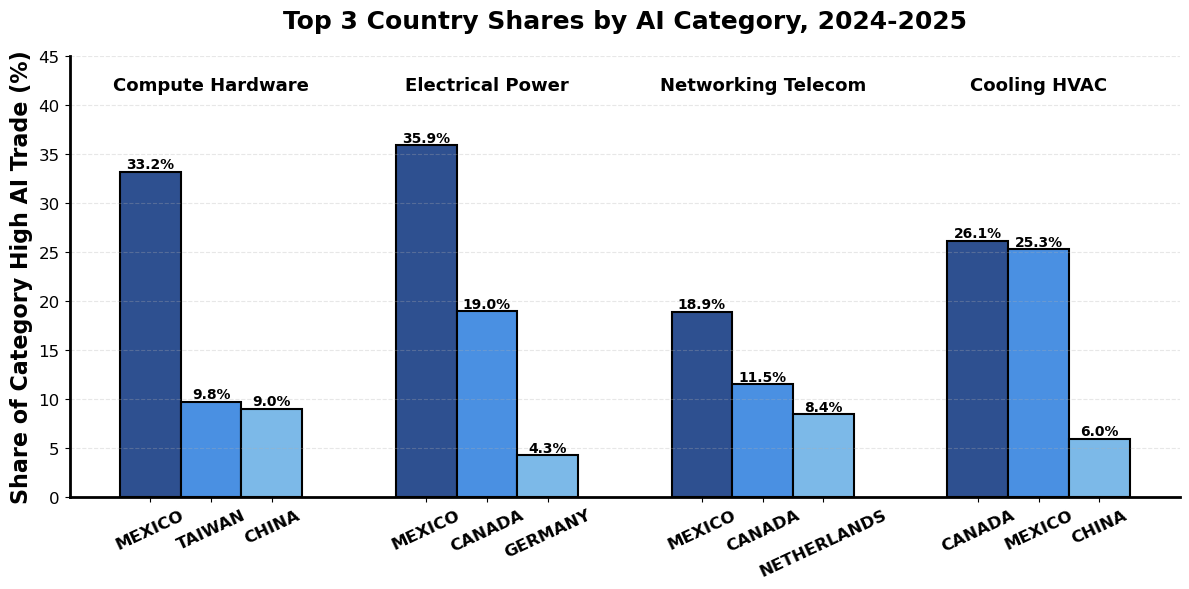


Top 3 country shares within each category (2024-2025):
  Compute Hardware:
    1) MEXICO: 33.2%
    2) TAIWAN: 9.8%
    3) CHINA: 9.0%
  Electrical Power:
    1) MEXICO: 35.9%
    2) CANADA: 19.0%
    3) GERMANY: 4.3%
  Networking Telecom:
    1) MEXICO: 18.9%
    2) CANADA: 11.5%
    3) NETHERLANDS: 8.4%
  Cooling HVAC:
    1) CANADA: 26.1%
    2) MEXICO: 25.3%
    3) CHINA: 6.0%


In [100]:
# Top 3 country shares within each top AI category (2024-2025)

period_years = [2024, 2025]
category_list = ['Compute_Hardware', 'Electrical_Power', 'Networking_Telecom', 'Cooling_HVAC']

cat_country_high = dfcountry[
    (dfcountry['relevance'] == 'High') &
    (dfcountry['primary_category'].isin(category_list)) &
    (dfcountry['time'].dt.year.isin(period_years))
] .copy()

# Compute top-3 country shares within each category
share_by_rank = {'Top 1': [], 'Top 2': [], 'Top 3': []}
country_names_by_cat = {}

for category in category_list:
    category_data = cat_country_high[cat_country_high['primary_category'] == category]
    country_exports = category_data.groupby('CTY_NAME', observed=True)['exports'].sum().sort_values(ascending=False)

    category_total = country_exports.sum()
    top3 = country_exports.head(3)

    # Pad if fewer than 3 countries
    top3_shares = (top3 / category_total * 100).tolist()
    top3_names = top3.index.tolist()

    while len(top3_shares) < 3:
        top3_shares.append(0.0)
        top3_names.append('N/A')

    share_by_rank['Top 1'].append(top3_shares[0])
    share_by_rank['Top 2'].append(top3_shares[1])
    share_by_rank['Top 3'].append(top3_shares[2])

    country_names_by_cat[category] = top3_names

# Plot grouped bars
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(category_list))
width = 0.22

bars_top1 = ax.bar(
    x - width,
    share_by_rank['Top 1'],
    width,
    label='Top 1 Country',
    color='#2E5090',
    edgecolor='black',
    linewidth=1.5
)

bars_top2 = ax.bar(
    x,
    share_by_rank['Top 2'],
    width,
    label='Top 2 Country',
    color='#4A90E2',
    edgecolor='black',
    linewidth=1.5
)

bars_top3 = ax.bar(
    x + width,
    share_by_rank['Top 3'],
    width,
    label='Top 3 Country',
    color='#7CB9E8',
    edgecolor='black',
    linewidth=1.5
)

# Labels on bars (percent values)
for bars in [bars_top1, bars_top2, bars_top3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.05,
            f'{height:.1f}%',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

# X-axis labels: country names under each bar
bar_positions = []
bar_labels = []
for idx, category in enumerate(category_list):
    c1, c2, c3 = country_names_by_cat[category]
    bar_positions.extend([x[idx] - width, x[idx], x[idx] + width])
    bar_labels.extend([c1, c2, c3])

ax.set_xticks(bar_positions)
ax.set_xticklabels(bar_labels)

# Category annotations centered on middle bar of each group (~42%)
max_share = max(max(share_by_rank['Top 1']), max(share_by_rank['Top 2']), max(share_by_rank['Top 3']))
category_label_y = 42
top_ylim = max(max_share * 1.22, category_label_y + 3)

for idx, category in enumerate(category_list):
    ax.text(
        x[idx],
        category_label_y,
        category.replace('_', ' '),
        ha='center',
        va='center',
        fontsize=13,
        fontweight='bold'
    )

# Formatting (consistent style)
ax.set_ylabel('Share of Category High AI Trade (%)', fontsize=16, fontweight='bold')
ax.set_title('Top 3 Country Shares by AI Category, 2024-2025', fontsize=18, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, top_ylim)

ax.tick_params(axis='x', labelsize=12, rotation=25)
ax.tick_params(axis='y', labelsize=12)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)



plt.tight_layout()
plt.show()

print('\nTop 3 country shares within each category (2024-2025):')
for category in category_list:
    c1, c2, c3 = country_names_by_cat[category]
    i = category_list.index(category)
    print(f"  {category.replace('_', ' ')}:")
    print(f"    1) {c1}: {share_by_rank['Top 1'][i]:.1f}%")
    print(f"    2) {c2}: {share_by_rank['Top 2'][i]:.1f}%")
    print(f"    3) {c3}: {share_by_rank['Top 3'][i]:.1f}%")